# Digit KNN Classifier — Screenshot Ground Truth

**Approach:**
1. Load labeled screenshots (`10987.png` → readout = `10.987`) as ground-truth digit crops
2. Fit PCA + K-NN in pixel space (one shared model, but predictions filtered per-position)
3. Classify every frame from the video with per-position constraints
4. Mark low-confidence frames as `NaN` → fall back to last known good reading
5. Output clean voltage CSV

**Position constraints:**
| Digit | Position | Allowed values |
|-------|----------|----------------|
| D0 | leftmost (tens) | 1 only |
| D1 | units | 0, 1 |
| D2 | 1st decimal | 0, 1, 2, 8, 9 |
| D3 | 2nd decimal | 0–9 |
| D4 | 3rd decimal | 0–9 |

In [40]:
# ── CONFIG — adjust these if anything looks off ───────────────────────────────
from pathlib import Path

VIDEO_PATH  = Path('2026.3.19-actuation2_voltage_out.mp4')
SCREENSHOT_DIR = Path('.')              # where 10987.png etc. live
VOLTAGE_CSV_OUT = Path('2026.3.19-actuation2_voltage_knn.csv')

# Digit column boundaries for the 64×24 video frame (same as analysis.ipynb)
DIGIT_COLS = [
    (5,  14),   # D0 — tens digit, always 1
    (18, 27),   # D1 — units digit, 0 or 1
    (27, 40),   # D2 — 1st decimal, in {0,1,2,8,9}
    (39, 52),   # D3 — 2nd decimal, 0-9
    (51, 64),   # D4 — 3rd decimal, 0-9
]
FRAME_W, FRAME_H = 64, 24   # canonical video frame size
CROP_W, CROP_H   = 24, 48   # each digit is upscaled to this

# Per-position allowed labels (None = all digits)
DIGIT_CONSTRAINTS = {
    0: [1],
    1: [0, 1],
    2: [0, 1, 2, 8, 9],
    3: None,
    4: None,
}

# KNN / PCA
N_COMPONENTS = 20   # PCA dims; increase if accuracy is low
N_NEIGHBORS  = 3    # KNN neighbours (odd to avoid ties)

# Confidence threshold multiplier (higher = accept more readings)
UNSURE_MULTIPLIER = 2.5

# Physical voltage bounds — readings outside this range are immediately uncertain
VOLTAGE_MIN = 10.75   # V
VOLTAGE_MAX = 11.40   # V

# How often to sample video (seconds)
SAMPLE_DT = 0.1

# Decimal position: 10987 → 10.987 (3 digits from the right)
DECIMAL_FROM_RIGHT = 3

# ── Force calibration ─────────────────────────────────────────────────────────
# Meter voltage → force. Calibration fit: force_g = CALIB_SLOPE * V + CALIB_INTERCEPT
# At 10x gain: divide force by GAIN_FACTOR
CALIB_SLOPE     = 0.1728857407   # g / V (at original gain)
CALIB_INTERCEPT = 0.9356479766   # g    (at original gain)
GAIN_FACTOR     = 10             # amplifier gain used in this experiment
# Alternatively, use the direct sensitivity (overrides slope/intercept if set):
FORCE_mN_PER_V  = 5.67           # mN per volt of meter reading (with 10x gain)
USE_SIMPLE_SENSITIVITY = True    # True → use FORCE_mN_PER_V; False → use slope/intercept

# ── Film geometry for stress calculation ──────────────────────────────────────
FILM_THICKNESS_MM = 0.01    # mm
FILM_WIDTH_MM     = 2.2     # mm
# cross-sectional area (mm²)
FILM_AREA_MM2 = FILM_THICKNESS_MM * FILM_WIDTH_MM

# ── Applied voltage waveform (for reference plot) ─────────────────────────────
V_APPLIED_AMP = 0.8    # V amplitude (±)
V_HALF_PERIOD = 100.0  # seconds per half-cycle (100 s at +0.8, 100 s at -0.8, ...)
V_START_POLARITY = +1  # +1 = starts positive

print('Config loaded.')
print(f'Film cross-section: {FILM_THICKNESS_MM} mm × {FILM_WIDTH_MM} mm = {FILM_AREA_MM2:.4f} mm²')

Config loaded.
Film cross-section: 0.01 mm × 2.2 mm = 0.0220 mm²


In [41]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from tqdm.auto import tqdm

print('Imports OK')

Imports OK


## Step 1 — Extract digit crops from labeled screenshots

Each screenshot filename encodes the ground-truth readout (e.g. `10987.png` → digits 1, 0, 9, 8, 7).

We resize every screenshot to the canonical 64×24 video frame size so the same `DIGIT_COLS` apply.

In [42]:
def screenshot_to_frame(img_bgra):
    """Resize screenshot → 64×24 uint8 thresholded green-channel frame."""
    # Use green channel (index 1 in BGR or BGRA)
    g = img_bgra[:, :, 1]
    # Resize to canonical frame size (nearest-neighbour keeps sharp edges)
    small = cv2.resize(g, (FRAME_W, FRAME_H), interpolation=cv2.INTER_AREA)
    _, thresh = cv2.threshold(small, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return thresh


def extract_digit_crop(frame_thresh, x0, x1, w=CROP_W, h=CROP_H):
    """Crop one digit column and upscale."""
    crop = frame_thresh[:, x0:x1]
    return cv2.resize(crop, (w, h), interpolation=cv2.INTER_NEAREST)


def filename_to_digits(stem):
    """'10987' → [1, 0, 9, 8, 7]"""
    s = stem.strip()
    if not s.isdigit() or len(s) != 5:
        return None
    return [int(c) for c in s]


# ── Load all labeled screenshots ─────────────────────────────────────────────
X_train = []   # flattened crops
y_train = []   # digit labels
P_train = []   # digit position (0-4)

screenshot_paths = sorted(SCREENSHOT_DIR.glob('*.png'))
# Keep only files whose stem is a 5-digit number
screenshot_paths = [p for p in screenshot_paths if filename_to_digits(p.stem) is not None]

print(f'Found {len(screenshot_paths)} labeled screenshots:')
for p in screenshot_paths:
    print(f'  {p.name} → digits {filename_to_digits(p.stem)}')

for p in screenshot_paths:
    digits = filename_to_digits(p.stem)
    img = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)  # BGRA
    if img is None:
        print(f'WARNING: could not read {p}')
        continue
    frame = screenshot_to_frame(img)
    for pos, (x0, x1) in enumerate(DIGIT_COLS):
        crop = extract_digit_crop(frame, x0, x1)
        X_train.append(crop.flatten().astype(np.float32) / 255.0)
        y_train.append(digits[pos])
        P_train.append(pos)

X_train = np.array(X_train)
y_train = np.array(y_train)
P_train = np.array(P_train)

print(f'\nTotal training crops: {len(X_train)}')
for d in sorted(set(y_train)):
    print(f'  digit {d}: {(y_train==d).sum()} examples')

Found 14 labeled screenshots:
  10864.png → digits [1, 0, 8, 6, 4]
  10930.png → digits [1, 0, 9, 3, 0]
  10949.png → digits [1, 0, 9, 4, 9]
  10976.png → digits [1, 0, 9, 7, 6]
  10987.png → digits [1, 0, 9, 8, 7]
  10990.png → digits [1, 0, 9, 9, 0]
  11004.png → digits [1, 1, 0, 0, 4]
  11008.png → digits [1, 1, 0, 0, 8]
  11073.png → digits [1, 1, 0, 7, 3]
  11075.png → digits [1, 1, 0, 7, 5]
  11186.png → digits [1, 1, 1, 8, 6]
  11208.png → digits [1, 1, 2, 0, 8]
  11215.png → digits [1, 1, 2, 1, 5]
  11218.png → digits [1, 1, 2, 1, 8]

Total training crops: 70
  digit 0: 15 examples
  digit 1: 25 examples
  digit 2: 3 examples
  digit 3: 2 examples
  digit 4: 3 examples
  digit 5: 2 examples
  digit 6: 3 examples
  digit 7: 4 examples
  digit 8: 6 examples
  digit 9: 7 examples


## Step 2 — Visualize crops (sanity check)

Make sure the segmentation is picking up real digits before training.

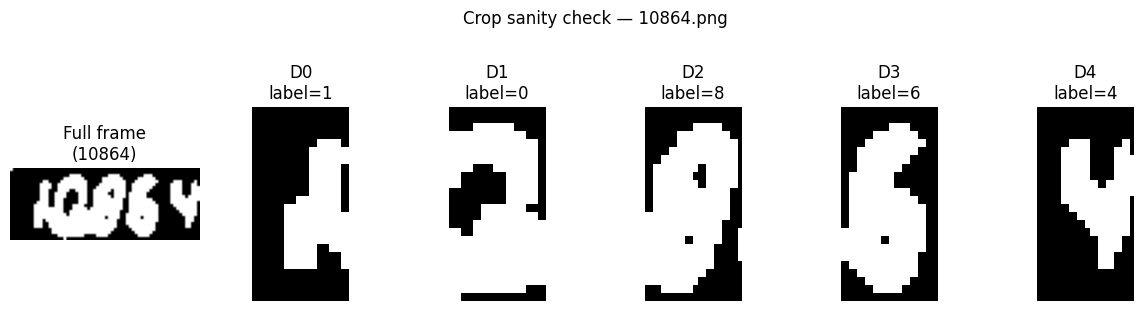

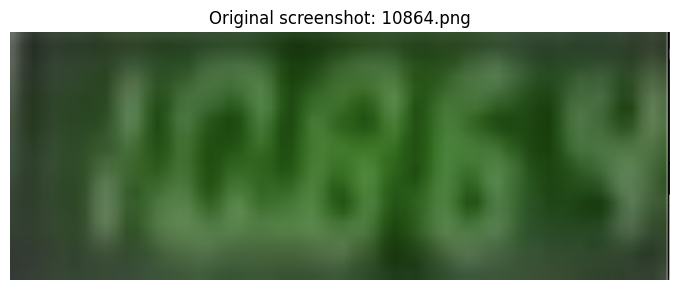

In [43]:
# Show all crops from the first screenshot
p0 = screenshot_paths[0]
img0 = cv2.imread(str(p0), cv2.IMREAD_UNCHANGED)
frame0 = screenshot_to_frame(img0)
digits0 = filename_to_digits(p0.stem)

fig, axes = plt.subplots(1, len(DIGIT_COLS) + 1, figsize=(12, 3))
axes[0].imshow(frame0, cmap='gray')
axes[0].set_title(f'Full frame\n({p0.stem})')
axes[0].axis('off')

for pos, (x0, x1) in enumerate(DIGIT_COLS):
    crop = extract_digit_crop(frame0, x0, x1)
    axes[pos + 1].imshow(crop, cmap='gray')
    axes[pos + 1].set_title(f'D{pos}\nlabel={digits0[pos]}')
    axes[pos + 1].axis('off')

plt.suptitle(f'Crop sanity check — {p0.name}', y=1.02)
plt.tight_layout()
plt.show()

# Also show the raw screenshot for comparison
fig2, ax2 = plt.subplots(figsize=(8, 3))
ax2.imshow(cv2.cvtColor(img0[:, :, :3], cv2.COLOR_BGR2RGB))
ax2.set_title(f'Original screenshot: {p0.name}')
ax2.axis('off')
plt.tight_layout()
plt.show()

## Step 3 — Fit PCA + K-NN classifier

PCA: 20 components, 88.5% variance explained
90th-pct NN dist (excl. self): 4.6703  →  unsure threshold: 11.6757 (×2.5)
  (all NN dists: min=1.0008  median=2.2430  max=7.4534)


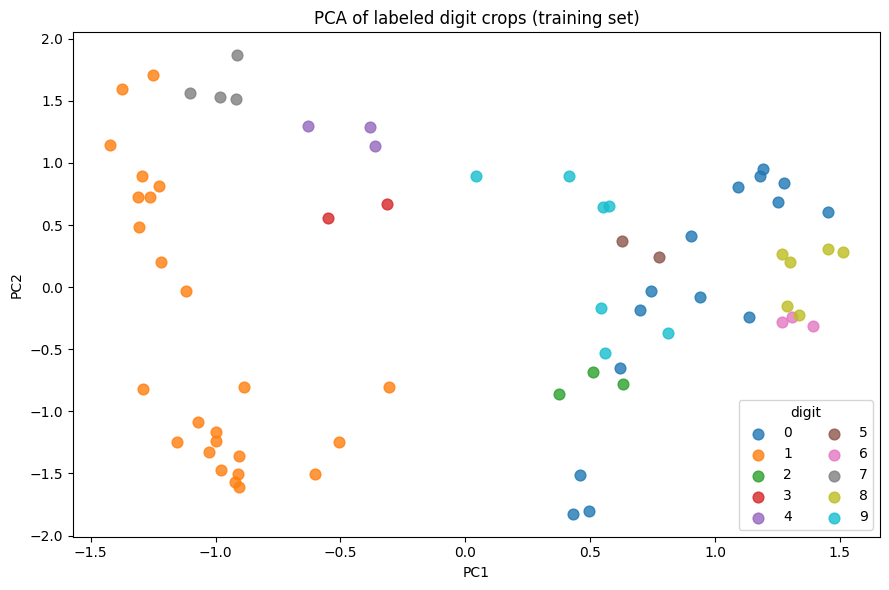

In [44]:
n_comp = min(N_COMPONENTS, len(X_train) - 1)
pca = PCA(n_components=n_comp, whiten=True, random_state=0)
X_pca = pca.fit_transform(X_train)

knn = KNeighborsClassifier(n_neighbors=min(N_NEIGHBORS, len(X_train)), metric='euclidean')
knn.fit(X_pca, y_train)

print(f'PCA: {pca.n_components_} components, '
      f'{pca.explained_variance_ratio_.sum()*100:.1f}% variance explained')

# Calibrate unsure threshold using cross-neighbour distances.
# kneighbors(X_pca) includes each sample itself at distance 0 —
# request k+1 and take column 1 to get the true nearest *other* sample.
cal_dists, _ = knn.kneighbors(X_pca, n_neighbors=min(N_NEIGHBORS + 1, len(X_train)))
nn_dists = cal_dists[:, 1]   # skip self (col 0 = 0)
ref_dist = np.percentile(nn_dists, 90)   # 90th pct of within-class NN distances
UNSURE_THRESHOLD = ref_dist * UNSURE_MULTIPLIER
print(f'90th-pct NN dist (excl. self): {ref_dist:.4f}  →  unsure threshold: {UNSURE_THRESHOLD:.4f} '
      f'(×{UNSURE_MULTIPLIER})')
print(f'  (all NN dists: min={nn_dists.min():.4f}  median={np.median(nn_dists):.4f}  max={nn_dists.max():.4f})')

# PCA scatter
fig, ax = plt.subplots(figsize=(9, 6))
for d in sorted(set(y_train)):
    mask = y_train == d
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=str(d), s=60, alpha=0.8)
ax.set(xlabel='PC1', ylabel='PC2', title='PCA of labeled digit crops (training set)')
ax.legend(title='digit', ncol=2)
plt.tight_layout()
plt.show()

## Step 4 — Classify all video frames

For each frame:
- Extract 5 digit crops (same preprocessing as screenshots)
- Project to PCA space, find K nearest neighbours
- Apply per-position constraint: restrict prediction to allowed labels
- If NN distance > threshold → mark digit as `NaN` (unsure)

In [45]:
def classify_digits(frame_gray):
    """
    Given a raw uint8 green-channel frame (64×24),
    returns a list of 5 predicted digits (int or None if unsure).
    """
    _, thresh = cv2.threshold(frame_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    crops = []
    for x0, x1 in DIGIT_COLS:
        crop = extract_digit_crop(thresh, x0, x1)
        crops.append(crop.flatten().astype(np.float32) / 255.0)

    X = np.array(crops)
    X_p = pca.transform(X)

    results = []
    for pos in range(len(DIGIT_COLS)):
        allowed = DIGIT_CONSTRAINTS[pos]  # None → no constraint

        # Get distances/indices to all training samples for this crop
        dists, idxs = knn.kneighbors(X_p[pos:pos+1], n_neighbors=len(X_train))
        dists = dists[0]
        idxs  = idxs[0]

        # Filter to allowed labels
        if allowed is not None:
            allowed_set = set(allowed)
            mask = np.array([y_train[i] in allowed_set for i in idxs])
            dists_f = dists[mask]
            idxs_f  = idxs[mask]
        else:
            dists_f = dists
            idxs_f  = idxs

        if len(dists_f) == 0:
            results.append(None)
            continue

        # Best match among allowed labels
        best_dist = dists_f[0]
        best_label = y_train[idxs_f[0]]

        if best_dist > UNSURE_THRESHOLD:
            results.append(None)   # unsure
        else:
            results.append(int(best_label))

    return results


# ── Sample video and classify ─────────────────────────────────────────────────
cap = cv2.VideoCapture(str(VIDEO_PATH))
fps = cap.get(cv2.CAP_PROP_FPS)
dur = cap.get(cv2.CAP_PROP_FRAME_COUNT) / fps
print(f'Video: {dur:.0f} s  |  {fps:.1f} fps')

timestamps = np.arange(0, dur, SAMPLE_DT)
raw_records = []   # (time_s, [d0, d1, d2, d3, d4]) — None for unsure digits

for t in tqdm(timestamps, desc='Classifying frames'):
    cap.set(cv2.CAP_PROP_POS_MSEC, t * 1000)
    ret, frame = cap.read()
    if not ret:
        raw_records.append((round(t, 3), [None]*5))
        continue
    g = frame[:, :, 1]   # green channel
    digits = classify_digits(g)
    raw_records.append((round(t, 3), digits))

cap.release()
print(f'Classified {len(raw_records)} timestamps.')

Video: 878 s  |  22.9 fps


Classifying frames: 100%|██████████| 8783/8783 [01:04<00:00, 137.09it/s]

Classified 8783 timestamps.


## Step 5 — Reconstruct voltage with last-known-good fallback

If any digit in a frame is `None` (unsure), the whole reading is `NaN` and we fall back to the previous confident reading.

In [46]:
DIGIT_WEIGHTS = [10.0, 1.0, 0.1, 0.01, 0.001]   # D0×10 + D1×1 + D2×0.1 + ...

def digits_to_voltage(digits):
    """Convert list of 5 ints → voltage float. Returns None if any digit is None."""
    if any(d is None for d in digits):
        return None
    v = round(sum(digits[i] * DIGIT_WEIGHTS[i] for i in range(5)), 4)
    # Immediately reject physically impossible readings
    if v < VOLTAGE_MIN or v > VOLTAGE_MAX:
        return None
    return v


rows = []
last_good = None

for t, digits in raw_records:
    v = digits_to_voltage(digits)
    if v is not None:
        last_good = v
    rows.append({
        'time_s':         t,
        'voltage_V':      v,
        'voltage_filled': last_good,   # last-known-good fallback
        'confident':      v is not None,
        'digits':         str(digits),
    })

df = pd.DataFrame(rows)
n_ok  = df['confident'].sum()
n_bad = (~df['confident']).sum()
print(f'Confident: {n_ok} ({100*n_ok/len(df):.1f}%)  |  Unsure/NaN: {n_bad} ({100*n_bad/len(df):.1f}%)')
df.head(10)

Confident: 8670 (98.7%)  |  Unsure/NaN: 113 (1.3%)


,time_s,voltage_V,voltage_filled,confident,digits
0,0.0,10.949,10.949,True,"[1, 0, 9, 4, 9]"
1,0.1,10.949,10.949,True,"[1, 0, 9, 4, 9]"
2,0.2,10.947,10.947,True,"[1, 0, 9, 4, 7]"
3,0.3,10.949,10.949,True,"[1, 0, 9, 4, 9]"
4,0.4,10.949,10.949,True,"[1, 0, 9, 4, 9]"
5,0.5,10.949,10.949,True,"[1, 0, 9, 4, 9]"
6,0.6,10.962,10.962,True,"[1, 0, 9, 6, 2]"
7,0.7,10.962,10.962,True,"[1, 0, 9, 6, 2]"
8,0.8,10.962,10.962,True,"[1, 0, 9, 6, 2]"
9,0.9,10.962,10.962,True,"[1, 0, 9, 6, 2]"


## Step 6 — Diagnostic plots

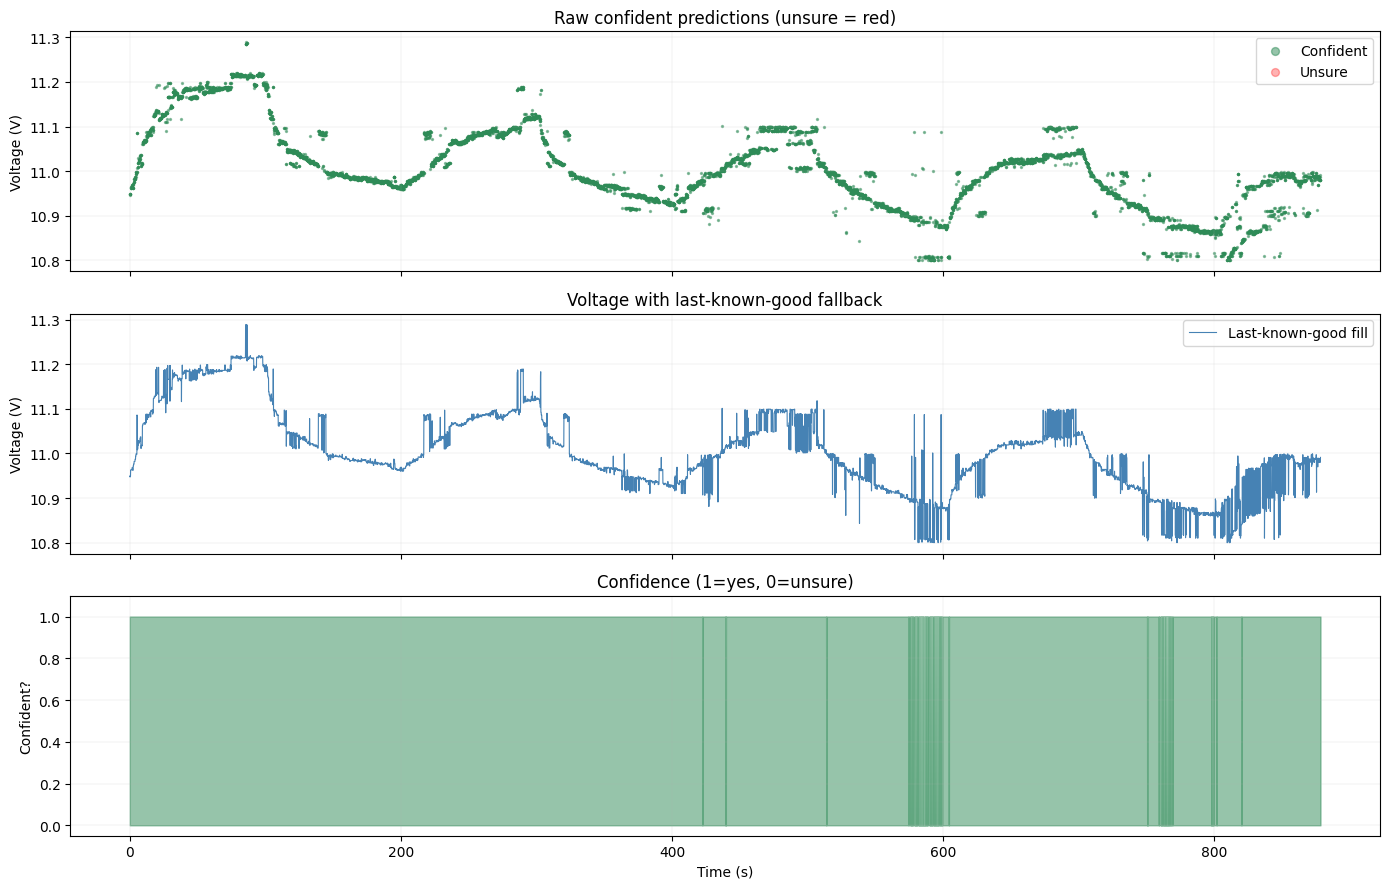

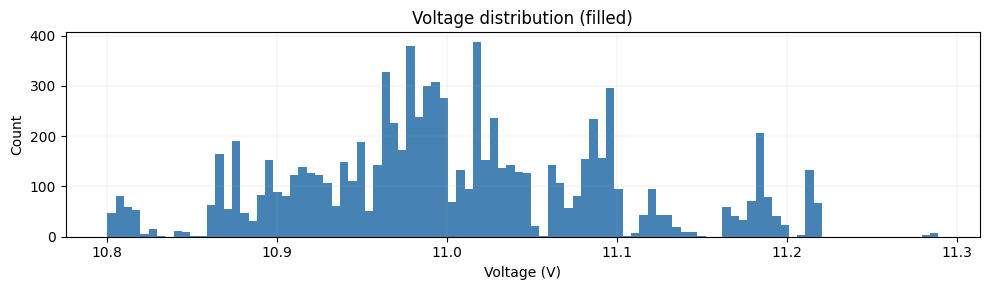

In [47]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Raw confident readings
conf = df[df['confident']]
axes[0].scatter(conf['time_s'], conf['voltage_V'], s=2, color='seagreen', alpha=0.5, label='Confident')
unconf = df[~df['confident']]
axes[0].scatter(unconf['time_s'], [np.nan]*len(unconf), s=2, color='red', alpha=0.3, label='Unsure')
axes[0].set(ylabel='Voltage (V)', title='Raw confident predictions (unsure = red)')
axes[0].legend(markerscale=4)

# Last-known-good filled
axes[1].plot(df['time_s'], df['voltage_filled'], lw=0.8, color='steelblue', label='Last-known-good fill')
axes[1].set(ylabel='Voltage (V)', title='Voltage with last-known-good fallback')
axes[1].legend()

# Confidence flag over time
axes[2].fill_between(df['time_s'], df['confident'].astype(int), alpha=0.5, color='seagreen')
axes[2].set(xlabel='Time (s)', ylabel='Confident?', title='Confidence (1=yes, 0=unsure)', ylim=[-0.05, 1.1])

for ax in axes:
    ax.grid(True, lw=0.3, alpha=0.4)

plt.tight_layout()
plt.show()

# Voltage histogram
fig2, ax2 = plt.subplots(figsize=(10, 3))
ax2.hist(df['voltage_filled'].dropna(), bins=100, color='steelblue', edgecolor='none')
ax2.set(xlabel='Voltage (V)', ylabel='Count', title='Voltage distribution (filled)')
ax2.grid(True, lw=0.3, alpha=0.4)
plt.tight_layout()
plt.show()

## Step 7 — Tune UNSURE_MULTIPLIER if needed

If the histogram shows weird spikes (wrong labels), **lower** `UNSURE_MULTIPLIER` in cell 1 and re-run from Step 3.  
If too many frames are unsure (large gaps in the confidence plot), **raise** it.

First 10 unsure timestamps: [422.3 439.3 439.6 513.7 574.3 575.8 576.3 576.5 576.9 577.5]


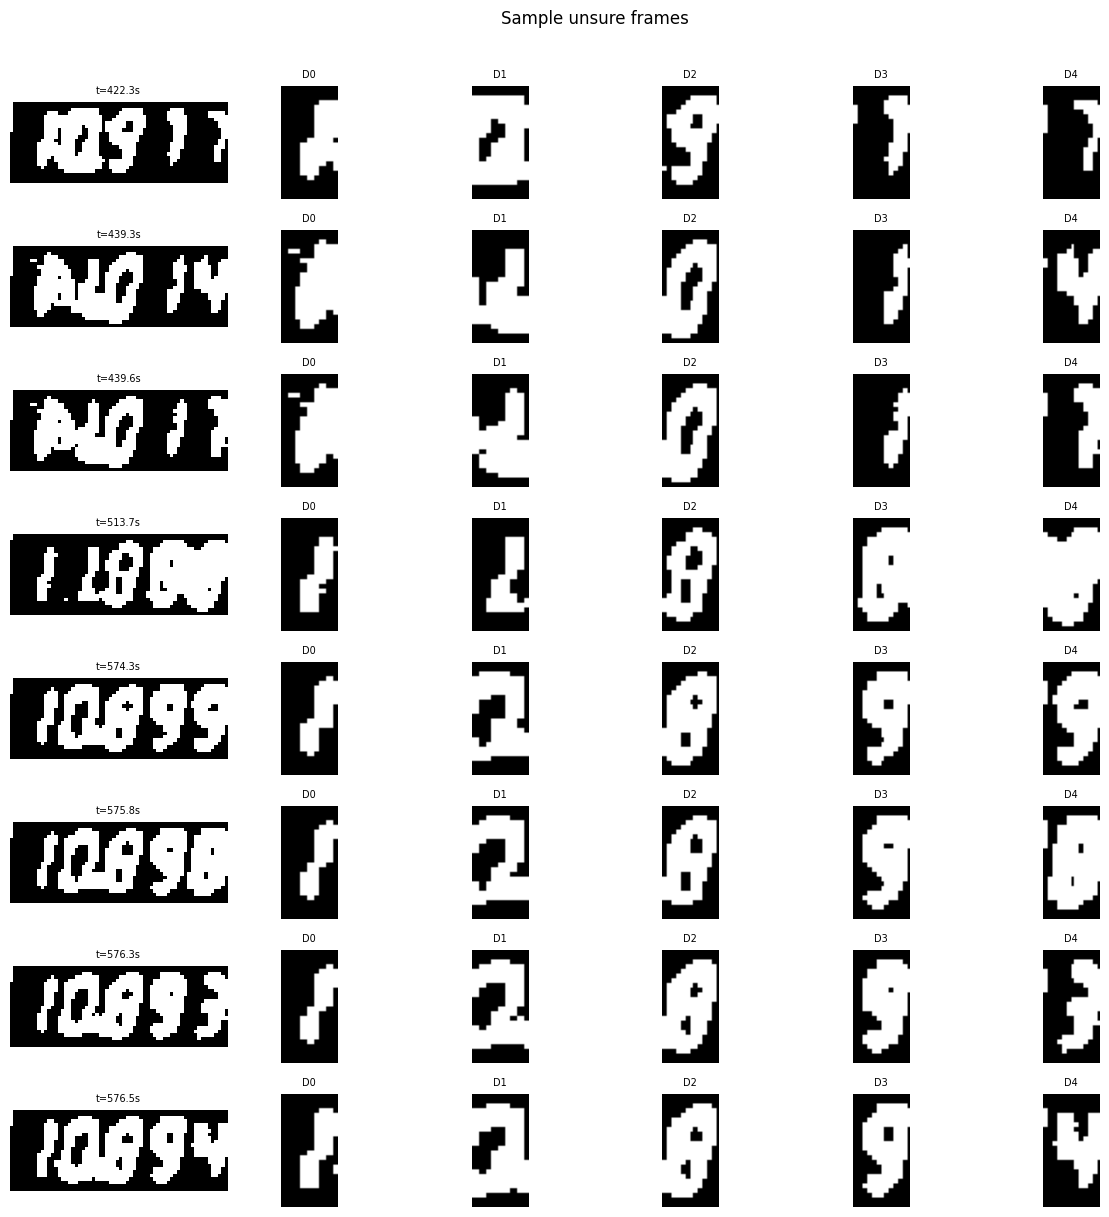

In [48]:
# Quick look at a few unsure frames to understand what they look like
unsure_times = df[~df['confident']]['time_s'].values
print(f'First 10 unsure timestamps: {unsure_times[:10]}')

if len(unsure_times) > 0:
    cap2 = cv2.VideoCapture(str(VIDEO_PATH))
    n_show = min(8, len(unsure_times))
    fig, axes = plt.subplots(n_show, len(DIGIT_COLS) + 1, figsize=(12, n_show * 1.5))
    if n_show == 1:
        axes = axes[np.newaxis, :]

    for row, t in enumerate(unsure_times[:n_show]):
        cap2.set(cv2.CAP_PROP_POS_MSEC, t * 1000)
        ret, frame = cap2.read()
        if not ret:
            continue
        g = frame[:, :, 1]
        _, thresh = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        axes[row, 0].imshow(thresh, cmap='gray')
        axes[row, 0].set_title(f't={t:.1f}s', fontsize=7)
        axes[row, 0].axis('off')

        for pos, (x0, x1) in enumerate(DIGIT_COLS):
            crop = extract_digit_crop(thresh, x0, x1)
            axes[row, pos + 1].imshow(crop, cmap='gray')
            axes[row, pos + 1].axis('off')
            axes[row, pos + 1].set_title(f'D{pos}', fontsize=7)

    cap2.release()
    plt.suptitle('Sample unsure frames', y=1.01)
    plt.tight_layout()
    plt.show()

## Step 8 — Save CSV

In [49]:
out = df[['time_s', 'voltage_filled', 'confident']].rename(
    columns={'voltage_filled': 'voltage_V'}
)
out.to_csv(VOLTAGE_CSV_OUT, index=False)
print(f'Saved → {VOLTAGE_CSV_OUT}')
print(out['voltage_V'].describe().to_string())

Saved → 2026.3.19-actuation2_voltage_knn.csv
count    8783.000000
mean       11.004478
std         0.091684
min        10.800000
25%        10.947000
50%        10.993000
75%        11.065000
max        11.289000


## Step 9 — Merge with current CSV and plot

Copy the sync/merge cells from `analysis.ipynb` if you want the full combined plot.

Cross-section: 0.0220 mm²  =  2.2000e-08 m²
Force range:   61.24 – 64.01 mN
Stress range:  2.783 – 2.909 MPa


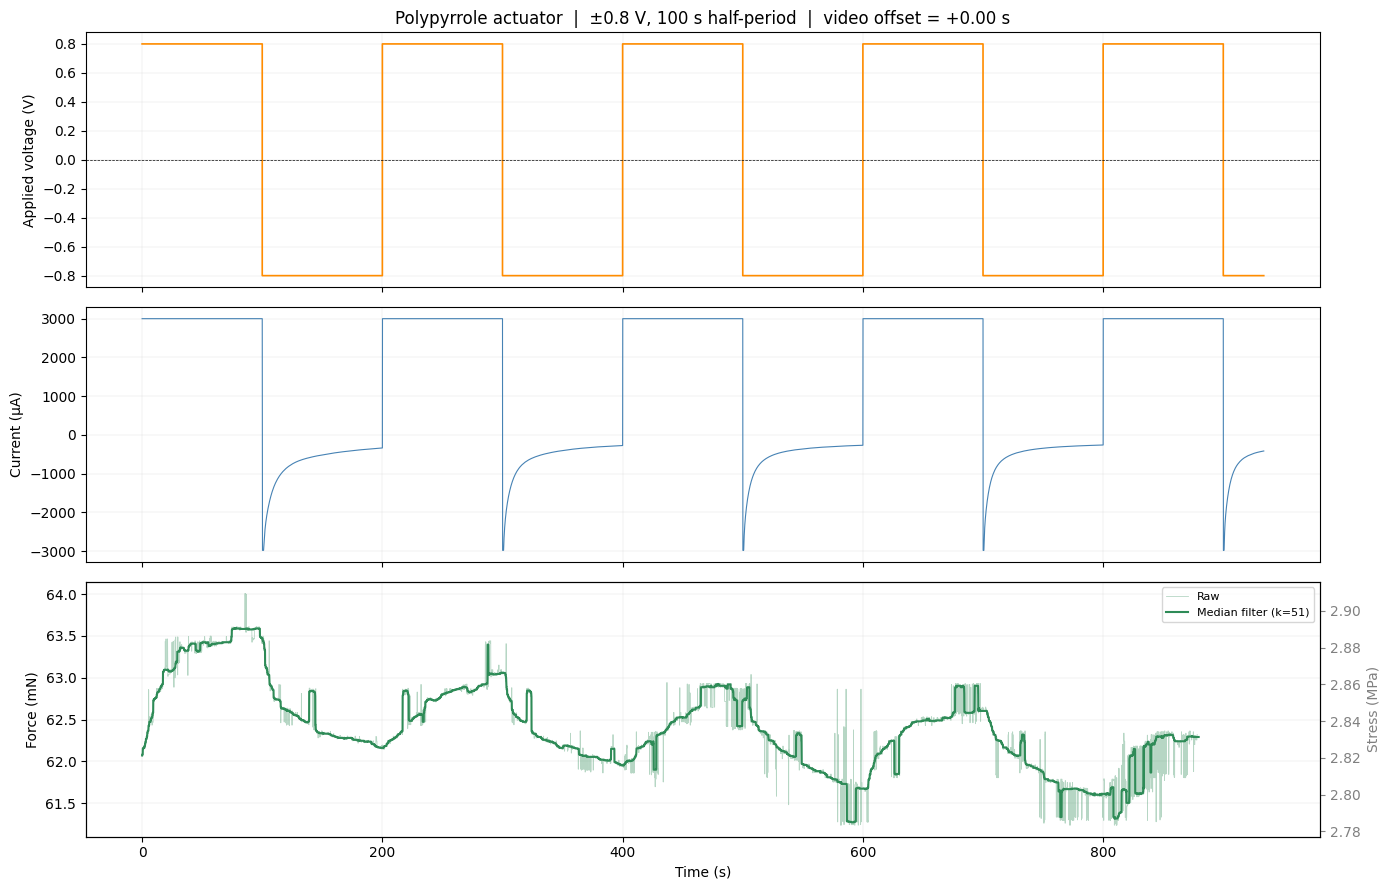

Saved merged CSV.


,time_s,voltage_V,force_mN,force_smooth_mN,stress_MPa,current_uA
count,9338.000000,8784.000000,8784.000000,8796.000000,8784.000000,9338.000000
mean,466.850000,11.004477,62.395384,62.402106,2.836154,1327.934094
std,269.579274,0.091679,0.519821,0.504828,0.023628,1824.070370
min,0.000000,10.800000,61.236000,61.270020,2.783455,-2983.520000
25%,233.425000,10.947000,62.069490,62.075160,2.821340,-407.873250
50%,466.850000,10.993000,62.330310,62.318970,2.833196,2998.720000
75%,700.275000,11.065000,62.738550,62.738550,2.851752,2998.720000
max,933.700000,11.289000,64.008630,63.594720,2.909483,2998.720000


In [50]:
from scipy.signal import medfilt

CSV_PATH = Path('2026.3.19-actuation2.csv')
VIDEO_OFFSET_S = 0.0   # ← tune this

df_current = pd.read_csv(CSV_PATH, encoding='utf-16', skiprows=5)
df_current.columns = ['time_s', 'current_uA']
df_current['time_s'] = pd.to_numeric(df_current['time_s'], errors='coerce')
df_current = df_current.dropna().reset_index(drop=True)

df_v = out.copy()
df_v['time_s_aligned'] = df_v['time_s'] + VIDEO_OFFSET_S

merged = pd.merge_asof(
    df_current.sort_values('time_s'),
    df_v.sort_values('time_s_aligned')[['time_s_aligned', 'voltage_V', 'confident']].rename(
        columns={'time_s_aligned': 'time_s'}
    ),
    on='time_s',
    direction='nearest',
    tolerance=0.15,
)

# ── Force conversion ──────────────────────────────────────────────────────────
if USE_SIMPLE_SENSITIVITY:
    merged['force_mN'] = merged['voltage_V'] * FORCE_mN_PER_V
else:
    merged['force_mN'] = (CALIB_SLOPE * merged['voltage_V'] + CALIB_INTERCEPT) * 9.81 / GAIN_FACTOR

# Median filter — kernel must be odd; ~5 s window at 0.1 s sampling = 51 samples
MEDFILT_KERNEL = 51   # ← tune: larger = smoother but less responsive
force_vals = merged['force_mN'].values
force_smooth = medfilt(force_vals, kernel_size=MEDFILT_KERNEL)

# ── Stress ────────────────────────────────────────────────────────────────────
area_m2 = FILM_AREA_MM2 * 1e-6
merged['stress_MPa']        = merged['force_mN'] * 1e-3 / area_m2 / 1e6
merged['stress_smooth_MPa'] = force_smooth        * 1e-3 / area_m2 / 1e6

print(f'Cross-section: {FILM_AREA_MM2:.4f} mm²  =  {area_m2:.4e} m²')
print(f"Force range:   {merged['force_mN'].min():.2f} – {merged['force_mN'].max():.2f} mN")
print(f"Stress range:  {merged['stress_MPa'].min():.3f} – {merged['stress_MPa'].max():.3f} MPa")

# ── Applied voltage waveform ──────────────────────────────────────────────────
t_arr = merged['time_s'].values
half_cycle = np.floor(t_arr / V_HALF_PERIOD).astype(int)
polarity   = np.where((half_cycle % 2) == 0, V_START_POLARITY, -V_START_POLARITY)
v_applied  = V_APPLIED_AMP * polarity

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Panel 1 — applied voltage
ax1.step(t_arr, v_applied, lw=1.2, color='darkorange', where='post')
ax1.axhline(0, color='black', lw=0.5, ls='--')
ax1.set(ylabel='Applied voltage (V)',
        title=f'Polypyrrole actuator  |  ±{V_APPLIED_AMP} V, {V_HALF_PERIOD:.0f} s half-period  |  video offset = {VIDEO_OFFSET_S:+.2f} s')
ax1.grid(True, lw=0.3, alpha=0.4)

# Panel 2 — current
ax2.plot(merged['time_s'], merged['current_uA'], lw=0.8, color='steelblue')
ax2.set(ylabel='Current (µA)')
ax2.grid(True, lw=0.3, alpha=0.4)

# Panel 3 — force (raw + smoothed) with stress on secondary axis
ax3.plot(merged['time_s'], merged['force_mN'], lw=0.6, color='seagreen', alpha=0.35, label='Raw')
ax3.plot(merged['time_s'], force_smooth, lw=1.5, color='seagreen', label=f'Median filter (k={MEDFILT_KERNEL})')
ax3.set(xlabel='Time (s)', ylabel='Force (mN)')
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(True, lw=0.3, alpha=0.4)

ax3b = ax3.twinx()
f_lim = ax3.get_ylim()
ax3b.set_ylim(np.array(f_lim) * 1e-3 / area_m2 / 1e6)
ax3b.set_ylabel('Stress (MPa)', color='grey')
ax3b.tick_params(axis='y', colors='grey')

plt.tight_layout()
plt.show()

merged['force_smooth_mN'] = force_smooth
merged.to_csv('2026.3.19-actuation2_merged_knn.csv', index=False)
print('Saved merged CSV.')
merged[['time_s', 'voltage_V', 'force_mN', 'force_smooth_mN', 'stress_MPa', 'current_uA']].describe()